# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [842]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [843]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [844]:
!ls
%mkdir data
!ls

data  drive  sample_data
mkdir: cannot create directory ‘data’: File exists
data  drive  sample_data


In [845]:
import shutil

# Copiar el archivo de Drive a Colab
shutil.copy("/content/drive/MyDrive/IA/DATASETS/Spotify_final_dataset.csv",
            "/content/data/Spotify_final_dataset.csv")

# Ahora lo cargas desde Colab
df = pd.read_csv("/content/data/Spotify_final_dataset.csv")
print("Primeras filas del dataset:")
print(df.head())


Primeras filas del dataset:
   Position    Artist Name                                   Song Name  Days  \
0         1   Post Malone   Sunflower  SpiderMan: Into the SpiderVerse  1506   
1         2    Juice WRLD                                 Lucid Dreams  1673   
2         3  Lil Uzi Vert                                XO TOUR Llif3  1853   
3         4       J. Cole                               No Role Modelz  2547   
4         5   Post Malone                                     rockstar  1223   

   Top 10 (xTimes)  Peak Position Peak Position (xTimes)  Peak Streams  \
0            302.0              1                  (x29)       2118242   
1            178.0              1                  (x20)       2127668   
2            212.0              1                   (x4)       1660502   
3              6.0              7                      0        659366   
4            186.0              1                 (x124)       2905678   

   Total Streams  
0      883369738  
1      8

Se carga el dataset de Spotify y se preprocesan las columnas necesarias. La columna “Peak Position (xTimes)” se convierte de texto a número. Seleccionamos dos características relevantes (Peak Streams y Top 10 (xTimes)) como variables de entrada X. La variable objetivo y se define como 1 si la canción es popular (más de 400 millones de streams) y 0 en caso contrario.

In [846]:
# Cargar datos
# Las dos primeras columnas contienen la nota de dos examenes y la tercera columna
# contiene la etiqueta que indica si el alumno ingreso o no a la universidad.
df = pd.read_csv("/content/drive/MyDrive/IA/DATASETS/Spotify_final_dataset.csv")

# X = primeras dos columnas, y = tercera columna
#X = data.iloc[:, 0:2]   # iloc = indexación por posición
#y = data.iloc[:, 2]

# Convertir Peak Position (xTimes) a numérico
df['Peak Position (xTimes)'] = df['Peak Position (xTimes)'].str.replace('(x', '', regex=False).str.replace(')', '', regex=False).astype(int)

# Selección de features
features = ['Peak Streams', 'Top 10 (xTimes)']
X = df[features].values

# y = 1 si Total Streams > 800 millones, 0 si no
y = (df['Total Streams'] > 400_000_000).astype(int).values

print(X)
print(y)

[[2.118242e+06 3.020000e+02]
 [2.127668e+06 1.780000e+02]
 [1.660502e+06 2.120000e+02]
 ...
 [4.654700e+04 0.000000e+00]
 [4.496200e+04 0.000000e+00]
 [4.432300e+04 0.000000e+00]]
[1 1 1 ... 0 0 0]


In [847]:
#Escalado de features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Agregar columna de unos para bias ---
m = X_scaled.shape[0]
X_with_bias = np.hstack([np.ones((m,1)), X_scaled])  # columna de 1

Se normalizan las características usando StandardScaler para que todas tengan media 0 y desviación estándar 1, evitando que las variables con valores grandes dominen el entrenamiento. Luego, se agrega una columna de unos para el término de intercepción (bias) de la regresión logística.

In [848]:
#División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Se divide el dataset en entrenamiento (80%) y prueba (20%). Esto permite entrenar el modelo con la mayoría de los datos y evaluar su desempeño en un conjunto independiente, evitando sobreajuste.

In [849]:
# Agregar columna de unos a X_test
m_test = X_test.shape[0]
X_test_with_bias = np.hstack([np.ones((m_test,1)), X_test])

# Predicciones sobre datos de prueba
y_pred_test = predict(theta, X_test_with_bias)

# Calcular precisión en el conjunto de prueba
accuracy_test = np.mean(y_pred_test == y_test) * 100
print(f'Precisión en el conjunto de prueba: {accuracy_test:.2f}%')


Precisión en el conjunto de prueba: 99.64%


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [850]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    #fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    #pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    #pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)
    pyplot.figure(figsize=(10,6))
    pyplot.scatter(X[pos, 0], X[pos, 1], marker='*', c='k', s=100)
    pyplot.scatter(X[neg, 0], X[neg, 1], marker='o', c='y', edgecolor='k', s=80)

Se llama a la función implementada para mostrar los datos cargados:

In [851]:

print("Número de canciones populares:", sum(y))
print("Número de canciones no populares:", len(y) - sum(y))

Número de canciones populares: 36
Número de canciones no populares: 11048


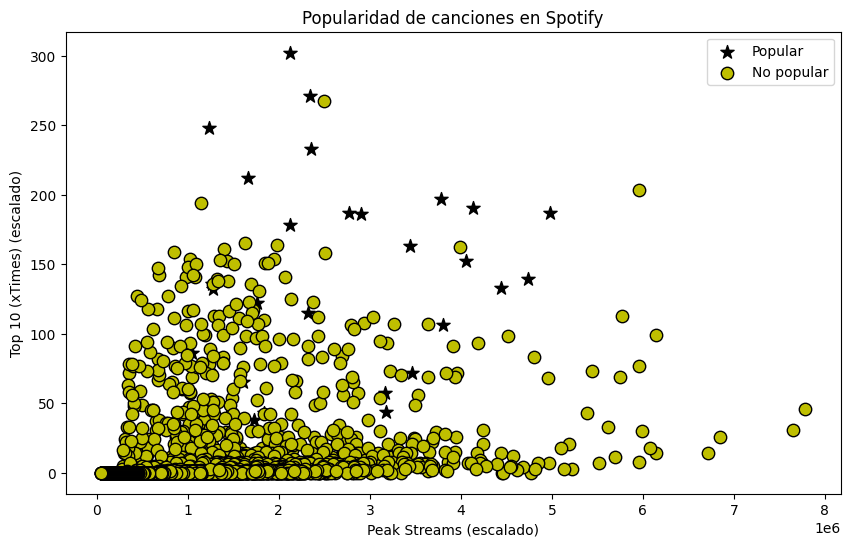

In [852]:
plotData(X, y)

# Etiquetas de los ejes
pyplot.xlabel('Peak Streams (escalado)')
pyplot.ylabel('Top 10 (xTimes) (escalado)')
pyplot.title('Popularidad de canciones en Spotify')

# Leyenda
pyplot.legend(['Popular', 'No popular'])
pyplot.show()


In [853]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [854]:
# Prueba la implementacion de la funcion sigmoid
z = 0
g = sigmoid(z)

print('g(', z, ') = ', g)

g( 0 ) =  0.5


La función sigmoide transforma cualquier valor real a un rango entre 0 y 1, lo que permite interpretar la salida como probabilidad de que una canción sea popular.

<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [855]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(X[5])

[1.00000e+00 9.77275e+05 4.00000e+00]


In [856]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = len(y)
    #m = y.size  # numero de ejemplos de entrenamiento
    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [857]:
def costFunction(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    J = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h))
    grad = (1/m) * (h - y).dot(X)
    return J, grad

def predict(theta, X):
    return np.round(sigmoid(X.dot(theta)))

In [858]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    m = len(y)
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

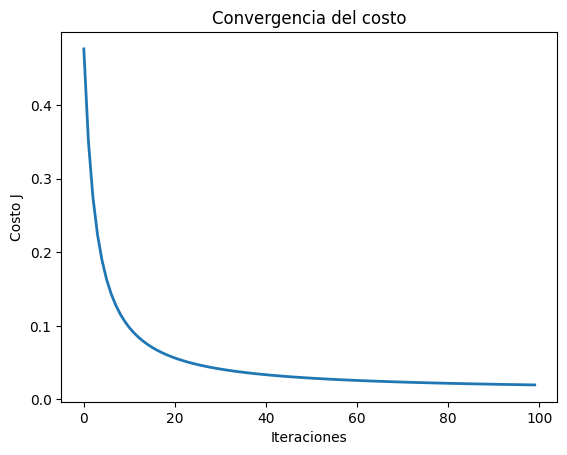

theta calculado por el descenso por el gradiente: [-4.51456331  0.1084659   0.32483418]


In [859]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 1
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_with_bias.shape[1])  # ahora theta tiene 3 elementos
theta, J_history = descensoGradiente(theta, X_with_bias, y, alpha, num_iters)

#Graficar convergencia del costo
pyplot.plot(J_history, lw=2)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# verificar si ingresa o no a la universidad
X_array = [1, 10, 10]
aprueba = sigmoid(np.dot(X_array, theta))   # Se debe cambiar esto

#print(f"Un estudiante con nota del examen 1: {X_array[1]} y nota del examen 2: {X_array[2]} (usando el descenso por el gradiente):{aprueba}")

In [860]:
# --- Predicción en un ejemplo ---
# ejemplo: Peak Streams=5,000,000 y Top 10 (xTimes)=10
X_ejemplo = np.array([1, 5e6, 10]).reshape(1, -1)
# Escalar las features del ejemplo
X_ejemplo[:,1:] = scaler.transform(X_ejemplo[:,1:])
prob = sigmoid(X_ejemplo @ theta.T)
print(f"Probabilidad de que la canción sea popular: {prob[0]:.2f}")

Probabilidad de que la canción sea popular: 0.03


In [861]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

Se prueba la funcion `costFunction` utilizando dos casos de prueba para $\theta$.

In [862]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n+1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad)
print('Gradiente en theta inicial (zeros):')
print('\t[{:.4f}, {:.4f}, {:.4f}]'.format(*grad))
print('Gradiente esperado (aproximado):\n\t[-0.1000, -12.0092, -11.2628]\n')



[0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

[4.96752075e-01 2.68987837e+05 9.88361602e-01]
Gradiente en theta inicial (zeros):
	[0.4968, 268987.8372, 0.9884]
Gradiente esperado (aproximado):
	[-0.1000, -12.0092, -11.2628]



In [863]:
# Calcula y muestra el costo y el gradiente con valores de theta diferentes a cero

test_theta = np.array([-24, 0.2, 0.2])
#test_theta = np.array([-11.74749157, 0.09927308, 0.09316497])
print(test_theta)
cost, grad = costFunction(test_theta, X, y)

print('Costo en theta prueba: {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.218\n')

print('Gradiente en theta prueba:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*grad))
print('Gradiente esperado (aproximado):\n\t[0.043, 2.566, 2.647]')

[-24.    0.2   0.2]
Costo en theta prueba: nan
Costo esperado (aproximado): 0.218

Gradiente en theta prueba:
	[0.997, 545461.282, 2.345]
Gradiente esperado (aproximado):
	[0.043, 2.566, 2.647]


/tmp/ipython-input-1056559099.py:10: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))


Parámetros de aprendizaje usando scipy.optimize

In [864]:
# Establecer las opciones para optimize.minimize
options= {'maxiter': 1000}

# revisar la documentacion de scipy's optimize.minimize para mayor descripcion de los parametros
# La funcion devuekve un objeto `OptimizeResult`
# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por `OptimizeResult`
# contiene el valor del costFunction de un theta optimizado
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

# Imprimir theta en la pantalla
print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.203\n');

print('theta:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*theta))
print('Theta esperado (aproximado):\n\t[-25.161, 0.206, 0.201]')

Costo con un valor de theta encontrado por optimize.minimize: 0.140
Costo esperado (aproximado): 0.203

theta:
	[-0.000, -0.000, 0.000]
Theta esperado (aproximado):
	[-25.161, 0.206, 0.201]


/tmp/ipython-input-1765194797.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


In [865]:
# OPTIMIZACIÓN
initial_theta = np.zeros(X_with_bias.shape[1])

res = optimize.minimize(
    fun=costFunction,
    x0=initial_theta,
    args=(X_with_bias, y),
    jac=True,
    method='TNC',
    options={'maxiter':500}
)

theta = res.x
print("Theta óptimo:", theta)
print("Costo final:", res.fun)

# EVALUACIÓN
p = predict(theta, X_with_bias)
accuracy = np.mean(p == y) * 100
print(f"Precisión de entrenamiento: {accuracy:.2f}%")

Theta óptimo: [-6.91765068  0.34965338  0.50912157]
Costo final: 0.012210157492361262
Precisión de entrenamiento: 99.74%


/tmp/ipython-input-342478812.py:4: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


Una vez que se completa `optimize.minimize`, se usa el valor final de $\theta$ para visualizar el límite de decisión en los datos de entrenamiento.

Para hacerlo, se implementa la función `plotDecisionBoundary` para trazar el límite de decisión sobre los datos de entrenamiento.

In [866]:
def plotData(X, y):
    pos = y == 1
    neg = y == 0
    pyplot.scatter(X[pos,0], X[pos,1], marker='*', c='k', s=100, label="Popular")
    pyplot.scatter(X[neg,0], X[neg,1], marker='o', c='y', edgecolor='k', s=80, label="No popular")

def plotDecisionBoundary(X, y, theta):
    pyplot.figure(figsize=(10,6))
    plotData(X[:,1:], y)   # quitamos columna de bias para graficar
    # frontera de decisión
    plot_x = np.array([X[:,1].min()-0.5, X[:,1].max()+0.5])
    plot_y = -(theta[0] + theta[1]*plot_x)/theta[2]
    pyplot.plot(plot_x, plot_y, "g-", linewidth=2, label="Frontera de decisión")
    pyplot.xlabel("Peak Streams (escalado)")
    pyplot.ylabel("Top 10 (xTimes) (escalado)")
    pyplot.title("Regresión logística - Spotify Popularidad")
    pyplot.legend()
    pyplot.show()


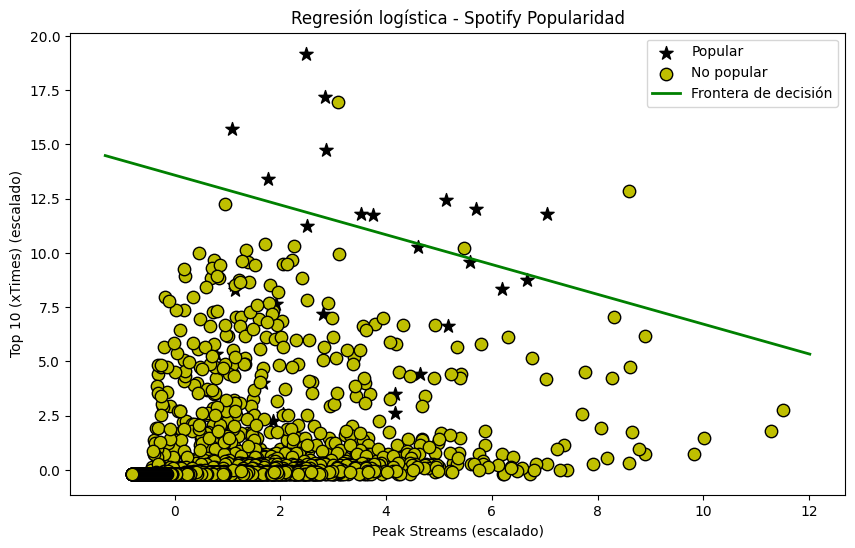

In [867]:
# Graficar limites
# X_with_bias: tu array numpy con columna de unos + features escaladas
plotDecisionBoundary(X_with_bias, y, theta)

<a id="section4"></a>
#### 1.2.4 Evaluación de la regresión logistica

Después de aprender los parámetros, se puede usar el modelo para predecir si un estudiante en particular será admitido. Para un estudiante con una puntuación en el Examen 1 de 45 y una puntuación en el Examen 2 de 85, debe esperar ver una probabilidad de admisión de 0,776. Otra forma de evaluar la calidad de los parámetros que hemos encontrado es ver qué tan bien predice el modelo aprendido en nuestro conjunto de entrenamiento.

In [868]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0] # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

Una vez entrenado el modelo se procede a realizar la prediccion y evaluación de los resultados de predecir cual es el valor que vota el modelo para todos los datos utilizados en el entrenamiento.

In [869]:
#  Predice la probabilidad de ingreso para un estudiante con nota de 45 en el examen 1 y nota de 85 en el examen 2
prob = sigmoid(np.dot([1, 45, 85], theta))
print('Para un estudiante con notas de 45 y 85, se predice una probabilidad de admisión de: {:.3f}%'.format(prob))
print('Valor esperado: 0.775 +/- 0.002\n')

# Compute accuracy on our training set
p = predict(theta, X)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))
print('Precisión esperada (aproximadamente): 89.00 %')

Para un estudiante con notas de 45 y 85, se predice una probabilidad de admisión de: 1.000%
Valor esperado: 0.775 +/- 0.002

Precisión de entrenamiento: 0.32 %
Precisión esperada (aproximadamente): 89.00 %


## Explicar el objetivo general del cuadernillo.

### Subtask:
Explicar el objetivo general del cuadernillo.


## Explicar la carga de datos y la exploración inicial, incluida la visualización.

### Subtask:
Explicar la carga de datos y la exploración inicial, incluida la visualización.


**Reasoning**:
Describe how the data is loaded and its structure, and then explain the plotting function and its use.

